In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys

In [2]:
%cd /content/drive/MyDrive/iot_sensors_prediction_classification


/content/drive/MyDrive/iot_sensors_prediction_classification/script


In [ ]:
sys.path.append(os.path.join(os.getcwd(), "script"))

In [3]:
import torch
import joblib
import torch.nn as nn
import numpy as np
from tqdm.auto import tqdm
from load_data import cls_data_train, cls_data_test
from torch.utils.data import DataLoader
from utils import learning_curve_pred,ClsDataset
from model import CNNMLP


In [ ]:
import json
with open("config.json", "r") as file:
    config = json.load(file)


In [7]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_dataset, val_dataset = cls_data_train()
test_dataset = cls_data_test()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
train_dl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_dl = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dl = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

new_cnnmlp = CNNMLP(input_channel=1,output_channel=3,num_cnn_layers=1,
                   num_mlp_layers=3,window_size=5, num_output_units=5)
new_cnnmlp.load_state_dict(torch.load(config["cnn_mlp_path"]))


class CNNMLPFeatureExtractor(nn.Module):
    def __init__(self, cnnmlp_model):
        super(CNNMLPFeatureExtractor, self).__init__()
        # get the cnn layers
        self.cnn_layers = cnnmlp_model.cnn

    def forward(self, x):
        return self.cnn_layers(x)

feature_extractor = CNNMLPFeatureExtractor(new_cnnmlp)
feature_extractor.eval()



CNNMLPFeatureExtractor(
  (feature_layers): Sequential(
    (0): Conv1d(1, 3, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (1): BatchNorm1d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(3, 3, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (4): BatchNorm1d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
  )
)

In [ ]:
#  Initialize lists to store features and targets, then iterate through the training and validation DataLoaders
# to extract features using the modified model and collect the corresponding target variables
train_features = []
train_targets = []
valid_features = []
valid_targets = []
test_features = []
test_targets = []

with torch.no_grad():
    for X, y in train_dl:
        # X= X.to(device)
        features = feature_extractor(X)
        train_features.append(features.cpu().numpy())
        train_targets.append(y.cpu().numpy())

    for X, y in valid_dl:
        # X = X.to(device)
        features = feature_extractor(X)
        valid_features.append(features.cpu().numpy())
        valid_targets.append(y.cpu().numpy())

    for X, y in test_dl:
        # X = X.to(device)
        features = feature_extractor(X)
        test_features.append(features.cpu().numpy())
        test_targets.append(y.cpu().numpy())

train_features = np.concatenate(train_features, axis=0)
train_targets = np.concatenate(train_targets, axis=0)
valid_features = np.concatenate(valid_features, axis=0)
valid_targets = np.concatenate(valid_targets, axis=0)
test_features = np.concatenate(test_features, axis=0)
test_targets = np.concatenate(test_targets, axis=0)

print("Training features shape:", train_features.shape)
print("Training targets shape:", train_targets.shape)
print("Validation features shape:", valid_features.shape)
print("Validation targets shape:", valid_targets.shape)
print("Test features shape:", test_features.shape)
print("Test targets shape:", test_targets.shape)

In [ ]:
import xgboost as xgb
# Create classification matrices
dtrain_clf = xgb.DMatrix(train_features, train_targets)
dvalid_clf = xgb.DMatrix(valid_features, valid_targets)
dtest_clf = xgb.DMatrix(test_features, test_targets)

In [9]:
# Xgboost
params = {
    "objective": "multi:softprob",
    "tree_method": "hist",
    "num_class": 5,
    "eval_metric": ["mlogloss", "auc", "merror"]
}

n = 100

# Cross-validation
results = xgb.cv(
    params,
    dtrain_clf,
    num_boost_round=n,
    nfold=5,
    verbose_eval=10
)


In [ ]:
# Save
joblib.dump(results, "/content/drive/MyDrive/iot_sensors_prediction_classification/trained_models/xgb_model.pkl")


In [10]:
# Load
model = joblib.load("/content/drive/MyDrive/iot_sensors_prediction_classification/trained_models/xgb_model.pkl")

## Results Analysis

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Predict class probabilities
y_test_pred_proba = model.predict(dtest_clf)
# Convert to class labels
y_test_pred = np.argmax(y_test_pred_proba, axis=1)


In [12]:
# test metrics
test_acc = accuracy_score(test_targets, y_test_pred)
test_prec = precision_score(test_targets, y_test_pred, average="weighted")
test_rec = recall_score(test_targets, y_test_pred, average="weighted")
test_f1 = f1_score(test_targets, y_test_pred, average="weighted")


print(f"Accuracy: {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall: {test_rec:.4f}")
print(f"F1 Score: {test_f1:.4f}")

Accuracy: 0.8192
Precision: 0.8282
Recall: 0.8192
F1 Score: 0.8183


In [13]:
cls_report = classification_report(test_targets, y_test_pred)
print(cls_report)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     88676
           1       0.69      0.61      0.65     88676
           2       1.00      1.00      1.00     88676
           3       0.64      0.84      0.72     88676
           4       0.82      0.64      0.72     88676

    accuracy                           0.82    443380
   macro avg       0.83      0.82      0.82    443380
weighted avg       0.83      0.82      0.82    443380



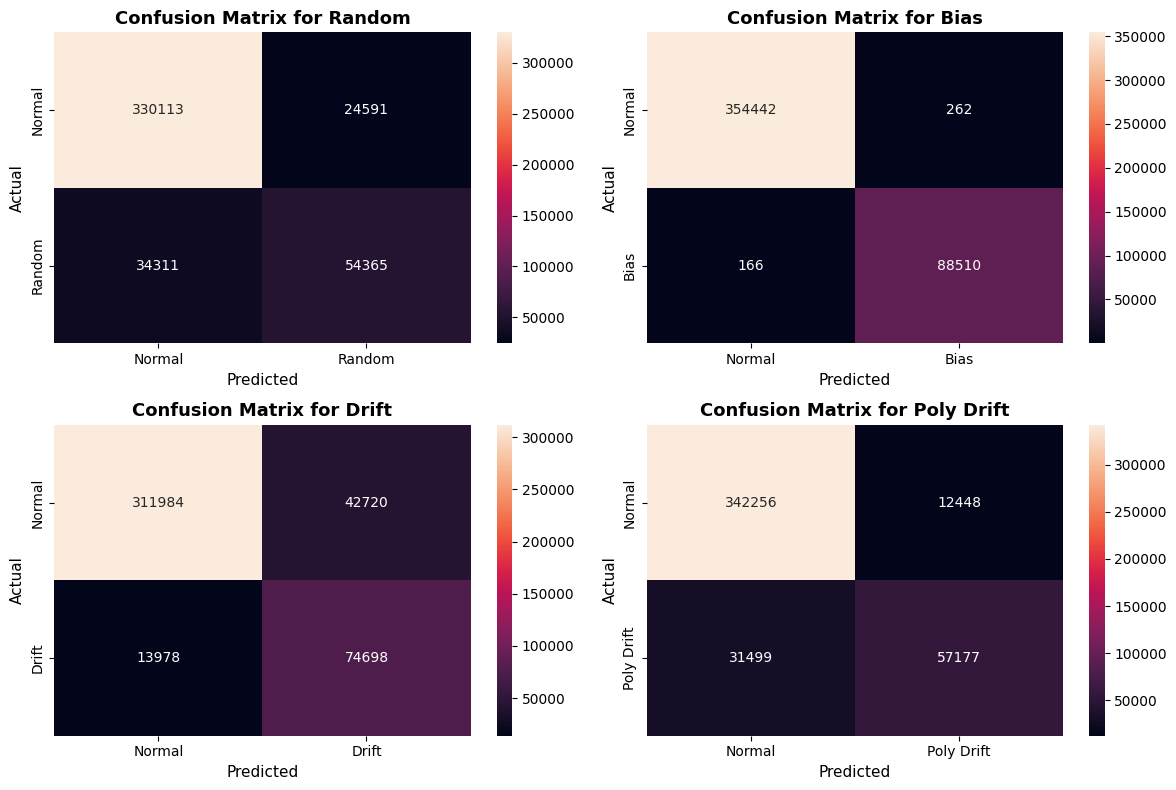

In [ ]:
from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define class label mappings
label_names = {
    0: "Normal",
    1: "Random",
    2: "Bias",
    3: "Drift",
    4: "Poly Drift"
}

# Compute confusion matrices for each class as one-vs-rest
labels = [0, 1, 2, 3, 4]
mcm = multilabel_confusion_matrix(test_targets, y_test_pred, labels=labels)

# Fault classes to visualize (skip class 0 "Normal")
fault_classes = [1, 2, 3, 4]

# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, cls in enumerate(fault_classes):
    row = i // 2
    col = i % 2
    ax = axes[row, col]

    matrix = mcm[cls]
    sns.heatmap(matrix, annot=True, fmt=".0f", cmap="rocket", cbar=True, ax=ax)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(["Normal", label_names[cls]])
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(["Normal", label_names[cls]])
    ax.set_title(f"Confusion Matrix for {label_names[cls]}", fontsize=13, weight='bold')

plt.tight_layout()
plt.show()
plt.savefig("/content/drive/MyDrive/iot_sensors_prediction_classification/figures/xgboost_cfmt.png")



## LIME

Local Interpretable Model-agnostic Explanations (LIME) is an XAI technique that provides a global understanding of the model on the entire dataset, LIME focuses on explaining the model’s prediction for individual instances.


In [ ]:
%pip install lime shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=ccadec6f50b1ebd1fba9e152a83fdc9bf4558fc479659c014d13fabb37d5bb19
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
from lime.lime_tabular import LimeTabularExplainer


# creating an instance of the lime tabular explainer and fitting it using the training data
lime_explainer = LimeTabularExplainer(training_data=train_features,
                                                   feature_names=[f'feature_{i}' for i in range(train_features.shape[1])],
                                                   class_names=["0", "1", "2","3","4"], mode="classification")


In [ ]:
import matplotlib.pyplot as plt
#  This generate lime explainer for the 0,1,2 instances of the test dataset
def xgb_predict(data):
    dmatrix = xgb.DMatrix(data)
    return model.predict(dmatrix)

num_explanations = 3 # number of input explanation to give
num_features_to_show = 10
explanations = []

for i in range(num_explanations):
    instance_to_explain = test_features[i]

    explanation = lime_explainer.explain_instance(
        data_row=instance_to_explain,
        predict_fn=xgb_predict,
        top_labels=5,
        num_features=num_features_to_show
    )

    explanations.append(explanation)
    print(f"Explanation for instance {i + 1}:")
    print(explanation.as_list())



Explanation for instance 1:
[('feature_14 <= 0.00', 0.11134872809823904), ('feature_13 <= 0.00', 0.10076941325964066), ('0.33 < feature_12 <= 3.17', -0.042864452523278154), ('1.51 < feature_10 <= 2.66', -0.04073926161261391), ('feature_11 <= 0.00', 0.03849562117848261), ('feature_4 <= 0.00', -0.02796321097864605), ('feature_0 > 0.00', 0.022518756743339904), ('feature_2 <= 0.00', -0.020864418192181208), ('feature_3 > 3.40', 0.017544981366996355), ('feature_5 <= 3.33', -0.016095710211184253)]
Explanation for instance 2:
[('feature_14 <= 0.00', 0.11570549799366062), ('feature_13 <= 0.00', 0.11555767865217773), ('feature_12 <= 0.00', 0.07072504466476941), ('0.60 < feature_10 <= 1.51', 0.04596735616963734), ('feature_11 <= 0.00', 0.03377162176357368), ('feature_0 > 0.00', 0.02953761397719562), ('0.76 < feature_4 <= 1.91', -0.02151541204455727), ('feature_3 > 3.40', 0.021260150522578056), ('feature_7 <= 0.00', -0.01470023414376549), ('feature_6 <= 0.30', 0.0085157140833392)]
Explanation for 

In [ ]:
# instance 1 only is shown here
explanations[1].show_in_notebook()

The result contains three main pieces of information from left to right:
-  the model’s predictions,
- features contributions, and
-  the actual value for each feature.

Keep in mind there are five classes {  0 ==> no fault, 2 ==> bias, 3 ==> drift, 4 ==> poly drift,  1 ==> random }.

 Therefore there are 5 vertical bar vision info. Each one contains the top 10 features that contributed to it being classifed as that class( features to the right), and features that that cotributed to it not being the class( to the left)

we see that instance 1 is predicted to have a fault type as 1( that is random fault) with a 72% confidence. The reasons that led the model to make this decision is because:

- Feature_14, 13, and 12  values are  0.00.
- Feature_10 is greater than 0.06 ( 1.47 on the table)
- Feature_ 0 is greater than 0 (1.64 on the table)
and so forth

These values are verified from the table on the right.

Explanation visualization for instance 1:


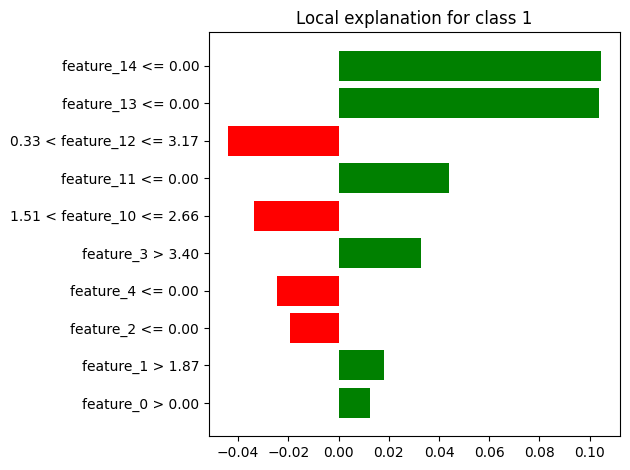

Explanation visualization for instance 2:


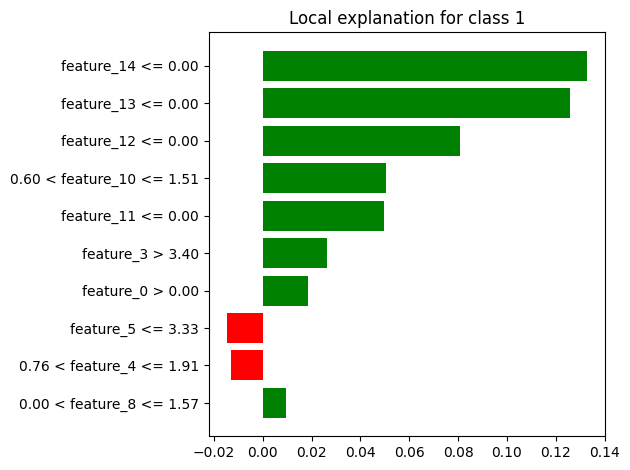

Explanation visualization for instance 3:


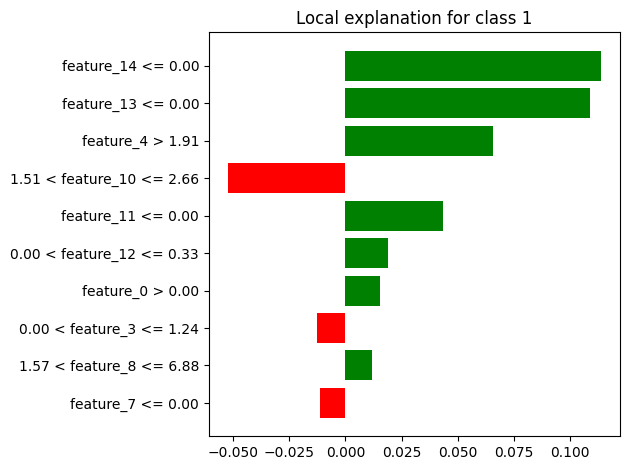

In [ ]:
# Plot the explanations
for i, explanation in enumerate(explanations):
    print(f"Explanation visualization for instance {i + 1}:")
    fig = explanation.as_pyplot_figure()
    plt.tight_layout()
    # fig.savefig(f"/content/drive/MyDrive/iot_sensors_prediction_classification/figures/lime_explanation_instance_{i+1}.png")
    plt.show()

Above, the three instances mentioned in the explanations are plotted, but only show the class they were classified int.  All three are classified as class 1 (random). This classification can be explained by the feature values on the y-axis (same as earlier)

###  SHAP

stands for SHapley Additive exPlanations. This method aims to explain the prediction of an instance/observation by computing the contribution of each feature to the prediction.


The TreeExplainer class is used to explain tree-based models. After instantiating the TreeExplainer class with our XGboost classifier, the shape values are computed for each feature of each instance in the test dataset.



In [14]:
# Create a TreeExplainer for the trained XGBoost model.
from shap import TreeExplainer

explainer_shap = TreeExplainer(model)

In [44]:
shap_values = explainer_shap.shap_values(test_features[:30000])

In [43]:
shap_values.shape

### Variable Importance with Summary Plot
In this plot, features are ranked by their average SHAP values showing the most important features at the top and the least important ones at the bottom using the summary_plot() function. This helps to understand the impact of each feature on the model’s predictions



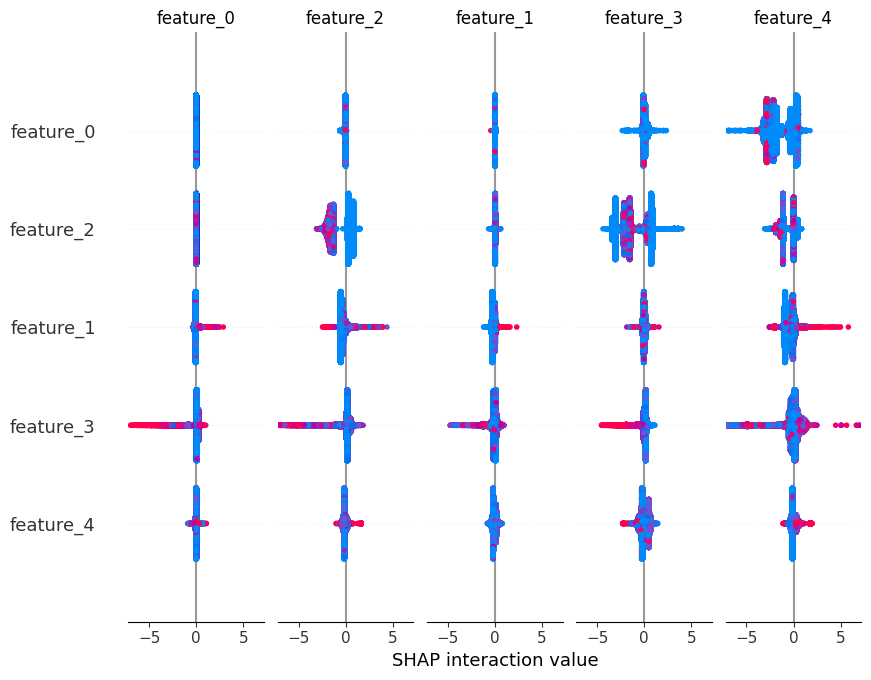

In [61]:
import shap
import os
import matplotlib.pyplot as plt

save_path = "/content/drive/MyDrive/iot_sensors_prediction_classification/figures"

# Generate a summary plot
shap.summary_plot(shap_values, test_features[:30000])
fig = plt.gcf()
fig.savefig(os.path.join(save_path, "shap_summary_plot.png"))
plt.close(fig)

##### From the above output, there are five vertical plot representing the five class label

the red and blue dots means high or low values that contributed to it being classified to that class or not.This is seen more clearly when whe plot individual class labels as shown below:


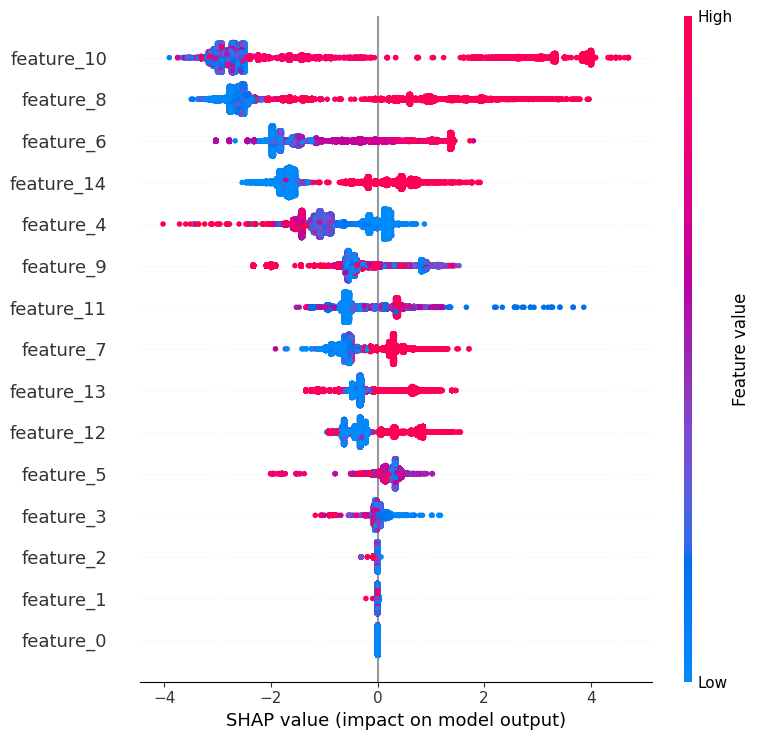

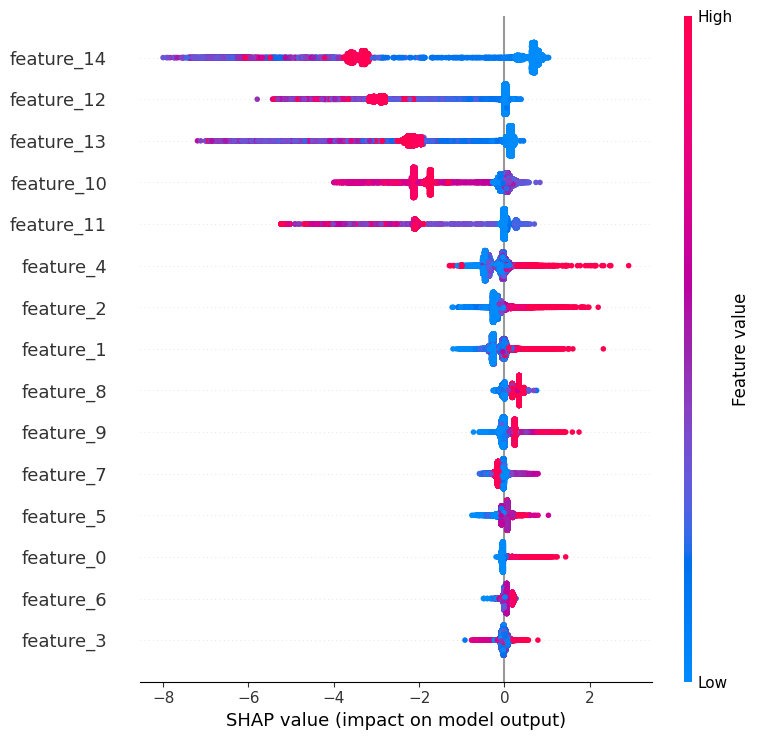

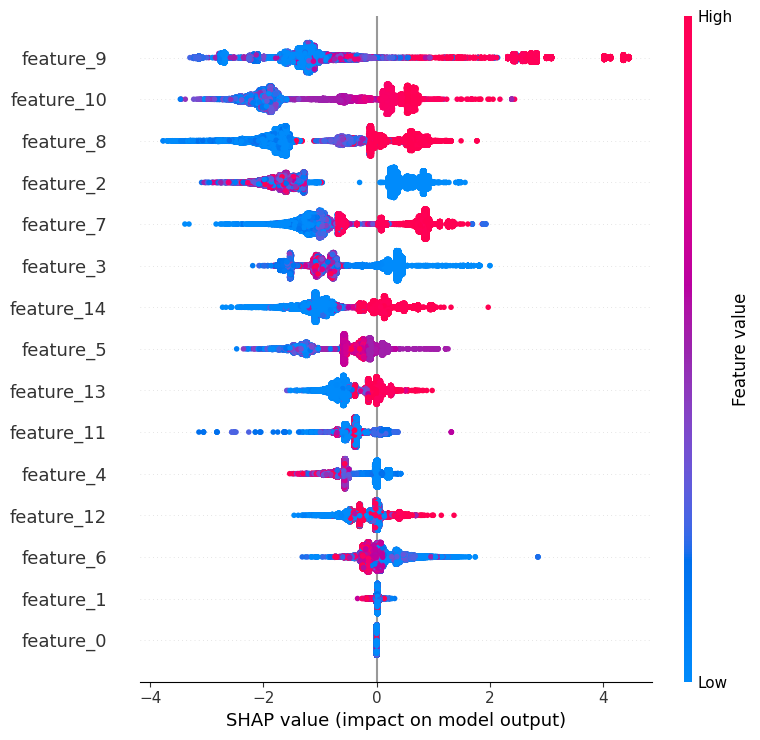

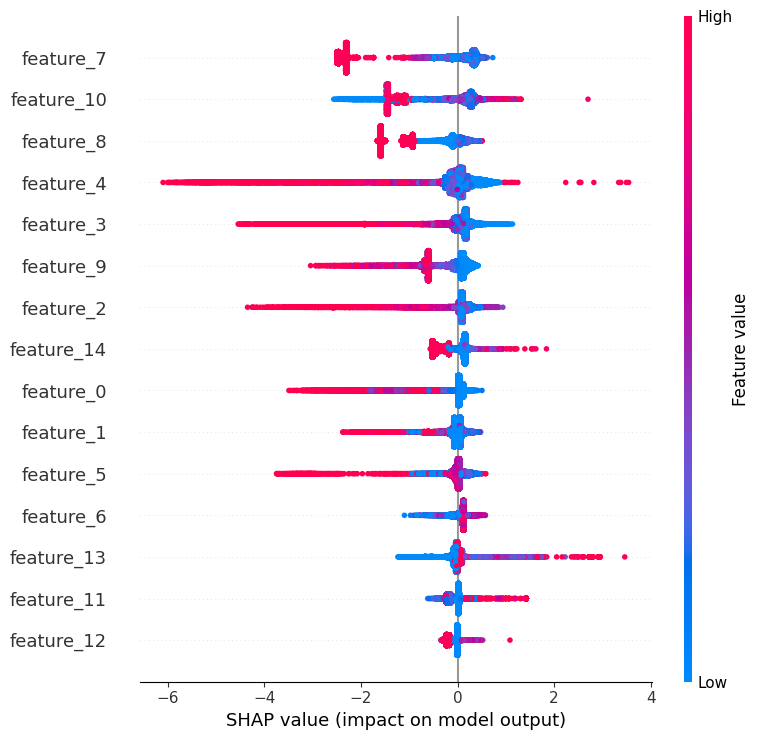

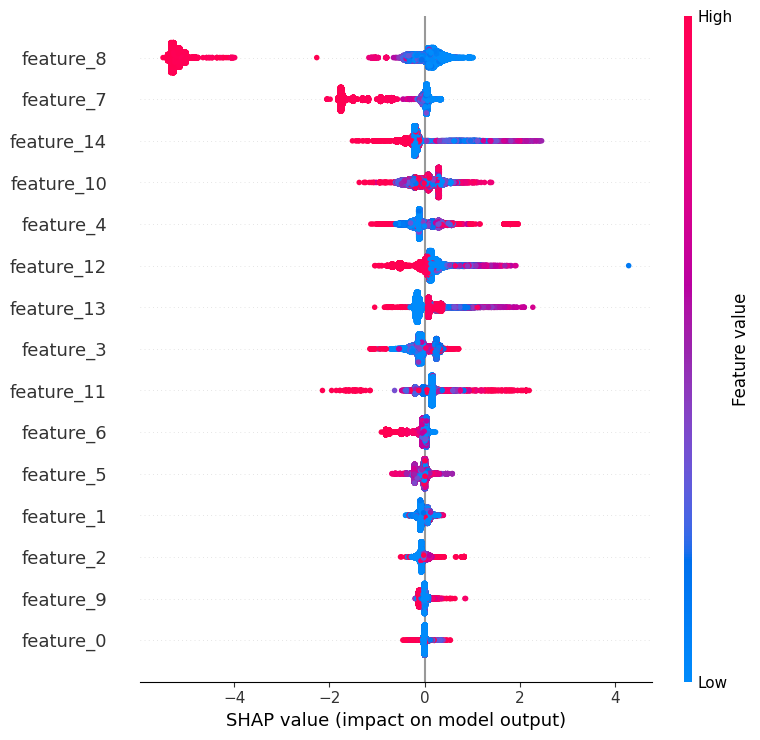

In [59]:
save_path = "/content/drive/MyDrive/iot_sensors_prediction_classification/figures"
for i in range(5): # loop through the five classes and plot a summary plot for each class.
  shap.summary_plot(shap_values[:,:,i], test_features[:30000])
  plt.savefig(os.path.join(save_path, f"summary_plot_class_{i}.png"))
  plt.close()

##### In the example below, shap_values[:,:,0] is used to represent the SHAP values for instances classified as label 0 (having no fault type).

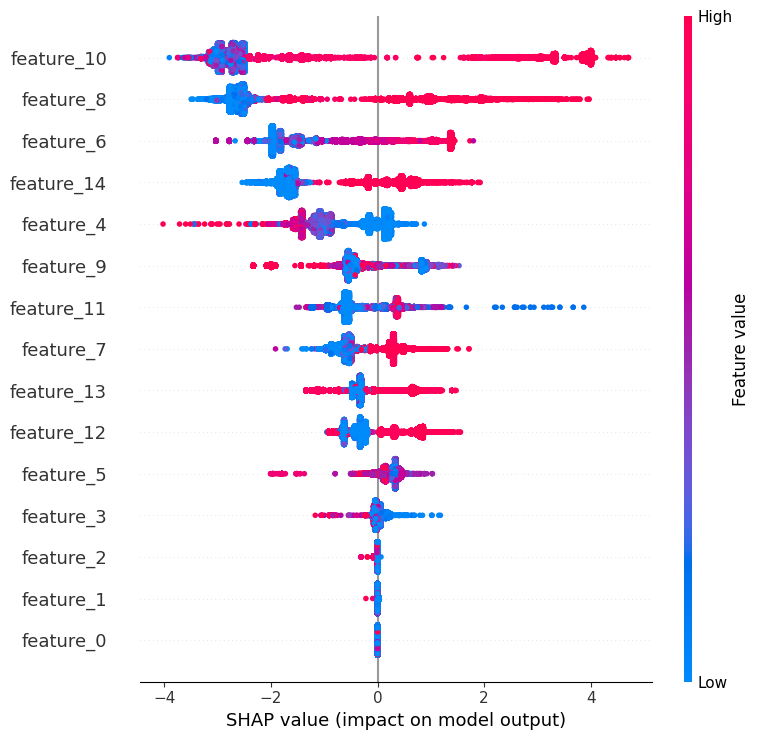

In [58]:
save_path = "/content/drive/MyDrive/iot_sensors_prediction_classification/figures"
shap.summary_plot(shap_values[:,:,0], test_features[:30000])
plt.savefig(os.path.join(save_path, "summary_plot_class_0.png"))
plt.close()

#### From the above graphic:

- Y-axis represents the features ranked by their average absolute SHAP values, similar to the graphic in 1 & 2.
- X-axis represents SHAP values. 
- The features are ordered in ascending order of importance
- Positive values for a given feature push the model’s prediction closer to the label being examined (label=0). In contrast, negative values push towards the opposite class (label= not 0).


A data instance with a high feature_10 value (red dots)  is likely to be classified as clean (positive outcome, label=0), while a low feature_10 value leads to it not being classified as clean, but other fault type.


In Constrast, an instance with high values of feature_4 is likely to be classified as *not clean* fault type, and low value classified as *clean*. 
While feature_1 and feature_0 are underterministic

In [60]:
# same as above but saves it correctly.
save_path = "/content/drive/MyDrive/iot_sensors_prediction_classification/figures"

for i in range(5):
    shap.summary_plot(
        shap_values[:, :, i],
        test_features[:30000],
        show=False prevents auto display
    )
    fig = plt.gcf()  # Get current figure generated by SHAP
    fig.savefig(os.path.join(save_path, f"summary_plot_class_{i}.png"))
    plt.close(fig)
